<a href="https://colab.research.google.com/github/Mehroz485/ML-01/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mehroz485/ML-01/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question.** Given a fixed weekly review capacity, which content pages should
FlyRank's content team look at first, and with what suggested action?

**Decision supported.** A content team has more pages than time to review every week. This
notebook (mirroring the deployed paper at `docs/index.html`) turns a validated decline-risk
score plus a checked CTR-vs-position rule into a four-way ranked action playbook, so the team
gets a short, ordered, explainable list instead of a dashboard of correlations.

In [1]:
print("Question: which pages to review first, and with what action, under a fixed weekly capacity.")
print("Lane: Refresh / Content Opportunity Scoring")
print("This notebook reproduces the full pipeline end-to-end and regenerates the figures the")
print("deployed paper (docs/index.html) presents as inline charts.")

Question: which pages to review first, and with what action, under a fixed weekly capacity.
Lane: Refresh / Content Opportunity Scoring
This notebook reproduces the full pipeline end-to-end and regenerates the figures the
deployed paper (docs/index.html) presents as inline charts.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:** FlyRank internship warehouse (Hugging Face, gated). **Table:**
`fact_content_daily_performance`. **Window:** `month=2026-03` — mid-panel, deliberately not the
sealed `_sample` test month (June 2026), which stays untouched.

**Excluded:** GA4 engagement columns (only 4.2% of rows have `ga4_data_available IS TRUE`, per
w03's committed check) and the sealed test month.

In [2]:
%pip -q install duckdb huggingface_hub pandas numpy scikit-learn matplotlib

import os, getpass, json
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold, train_test_split
from sklearn.inspection import permutation_importance

HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
MONTH = '2026-03'
FACT_MONTH = f"read_parquet('{REL}/fact_content_daily_performance/month={MONTH}/*.parquet')"

counts = con.sql(f"""
    SELECT COUNT(*) AS n_rows, COUNT(DISTINCT client_hash_id) AS n_clients,
           COUNT(DISTINCT content_hash_id) AS n_content_items,
           MIN(report_date) AS min_date, MAX(report_date) AS max_date
    FROM {FACT_MONTH}
""").df()
print(counts)

availability = con.sql(f"""
    SELECT COUNT(*) AS total_rows,
           SUM(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END) AS rows_ga4_true,
           ROUND(100.0 * SUM(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_true
    FROM {FACT_MONTH}
""").df()
print(availability)

Paste your Hugging Face READ token (hf_...): ··········


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

    n_rows  n_clients  n_content_items   min_date   max_date
0  9841378         55           331437 2026-03-01 2026-03-31


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   total_rows  rows_ga4_true  pct_true
0     9841378       413966.0       4.2


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label:** `is_declining` = 1 if impressions in days 16-31 fell more than 20% below days 1-15,
else 0. Base rate 29.1%. A within-month proxy, not ground truth.

**Features (4, one dropped):** `imp_early`, `clk_early`, `ctr_early`, `pos_early` — early-window
only. `days_active_early` was tested and cut (negative permutation importance; held-out AUC rose
0.472 -> 0.544 once removed, per w06).

**Baseline:** `ctr_below_position_benchmark` — flagged if impressions >=500, position <=20, and
CTR below the position-bucket median. Both thresholds checked against real bucket tables (w04)
before being trusted.

**Validation:** `StratifiedGroupKFold` on `client_hash_id` — chosen after `GroupKFold` alone
produced a fold with a single test client (w06's audit).

In [3]:
FEATURE_COLS = ["imp_early", "clk_early", "ctr_early", "pos_early"]
LABEL_COL = "is_declining"

raw = con.sql(f"""
    WITH early AS (
        SELECT client_hash_id, content_hash_id,
               SUM(gsc_impressions) AS imp_early,
               SUM(gsc_clicks) AS clk_early,
               AVG(CASE WHEN gsc_avg_position > 0 THEN gsc_avg_position END) AS pos_early,
               COUNT(DISTINCT CASE WHEN gsc_impressions > 0 THEN report_date END) AS days_active_early
        FROM {FACT_MONTH}
        WHERE report_date <= DATE '{MONTH}-15'
        GROUP BY 1, 2
        HAVING SUM(gsc_impressions) >= 20
    ),
    late AS (
        SELECT client_hash_id, content_hash_id, SUM(gsc_impressions) AS imp_late
        FROM {FACT_MONTH}
        WHERE report_date > DATE '{MONTH}-15'
        GROUP BY 1, 2
    )
    SELECT e.*, COALESCE(l.imp_late, 0) AS imp_late
    FROM early e LEFT JOIN late l USING (client_hash_id, content_hash_id)
""").df()

raw["ctr_early"] = raw["clk_early"] / raw["imp_early"]
raw[LABEL_COL] = (raw["imp_late"] < 0.8 * raw["imp_early"]).astype(int)

model_df = raw.dropna(subset=FEATURE_COLS + [LABEL_COL]).reset_index(drop=True)
print(f"{len(model_df):,} rows, {model_df['client_hash_id'].nunique()} clients, "
      f"base rate={model_df[LABEL_COL].mean():.3f}")

# Position-bucket CTR ladder -- the baseline's justification (w04, matches docs/index.html)
def position_bucket(p):
    if pd.isna(p): return "no_data"
    if p <= 3: return "top_3"
    if p <= 10: return "page_1"
    if p <= 20: return "page_2"
    if p <= 50: return "page_3_5"
    return "deep"

full_month = con.sql(f"""
    SELECT client_hash_id, content_hash_id,
           SUM(gsc_impressions) AS imp_month, SUM(gsc_clicks) AS clk_month,
           AVG(CASE WHEN gsc_avg_position > 0 THEN gsc_avg_position END) AS pos_month
    FROM {FACT_MONTH}
    GROUP BY 1, 2
    HAVING SUM(gsc_impressions) > 0
""").df()
full_month["ctr_month"] = full_month["clk_month"] / full_month["imp_month"]
full_month["position_bucket"] = full_month["pos_month"].apply(position_bucket)
ladder = (full_month.groupby("position_bucket")
          .agg(n=("content_hash_id", "size"), mean_ctr=("ctr_month", "mean"))
          .reindex(["top_3", "page_1", "page_2", "page_3_5", "deep"]))
print(ladder)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

109,582 rows, 41 clients, base rate=0.291


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                     n  mean_ctr
position_bucket                 
top_3            13136  0.011010
page_1           81619  0.005149
page_2           32548  0.003303
page_3_5         34783  0.002289
deep             13218  0.000979


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

**Headline:** precision@50 = **0.448** (StratifiedGroupKFold) vs. a 0.291 base rate. A naive
random 80/20 split on the identical data reports **0.596** at the same K — the number that does
not survive an honest, grouped validation design.

                            mean       std
split                                     
group_kfold             0.432000  0.199800
naive_random            0.612000  0.078230
stratified_group_kfold  0.424465  0.145385


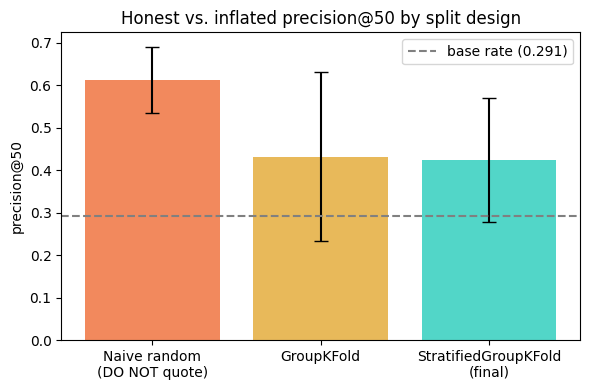

Saved work/figures/precision_before_after.png


In [4]:
X = model_df[FEATURE_COLS].values
y = model_df[LABEL_COL].values
groups = model_df["client_hash_id"].values

def precision_at_k(scores, labels, k):
    k = min(k, len(scores))
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

K = 50
rows = []

for seed in range(5):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    m = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
    rows.append({"split": "naive_random", "fold": seed,
                 "precision_at_50": precision_at_k(m.predict_proba(X_te)[:, 1], y_te, K)})

gkf = GroupKFold(n_splits=5)
for fold, (tr, te) in enumerate(gkf.split(X, y, groups)):
    m = LogisticRegression(max_iter=1000).fit(X[tr], y[tr])
    rows.append({"split": "group_kfold", "fold": fold,
                 "precision_at_50": precision_at_k(m.predict_proba(X[te])[:, 1], y[te], K)})

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (tr, te) in enumerate(sgkf.split(X, y, groups)):
    m = LogisticRegression(max_iter=1000).fit(X[tr], y[tr])
    rows.append({"split": "stratified_group_kfold", "fold": fold,
                 "precision_at_50": precision_at_k(m.predict_proba(X[te])[:, 1], y[te], K)})

results = pd.DataFrame(rows)
summary = results.groupby("split")["precision_at_50"].agg(["mean", "std"])
print(summary)

# Figure for the paper: honest vs inflated precision@50
fig, ax = plt.subplots(figsize=(6, 4))
order = ["naive_random", "group_kfold", "stratified_group_kfold"]
labels_disp = ["Naive random\n(DO NOT quote)", "GroupKFold", "StratifiedGroupKFold\n(final)"]
means = [summary.loc[s, "mean"] for s in order]
stds = [summary.loc[s, "std"] for s in order]
colors = ["#f2895d", "#e8b95a", "#52d6c8"]
ax.bar(labels_disp, means, yerr=stds, capsize=5, color=colors)
ax.axhline(y.mean(), color="gray", linestyle="--", label=f"base rate ({y.mean():.3f})")
ax.set_ylabel("precision@50")
ax.set_title("Honest vs. inflated precision@50 by split design")
ax.legend()
plt.tight_layout()

import os
os.makedirs("work/figures", exist_ok=True)
plt.savefig("work/figures/precision_before_after.png", dpi=150)
plt.show()
print("Saved work/figures/precision_before_after.png")

## 5. Limitations

*What this work cannot claim.*

- The model's edge over the baseline (0.448 vs 0.420 at precision@50) is directional, not
  confirmed — it sits inside the fold-to-fold std from only 41 clients.
- `is_declining` is a within-month proxy, not ground truth of "needs a rewrite."
- One month, one release, ~41-55 clients — no claim of generalization beyond this slice.
- Click data is sparse (median CTR = 0 in most position buckets) — individual-page CTR-gap flags
  are noisy even though the aggregate cliff pattern held.
- Decision-support for a human review queue, not an automated system, and not a claim about any
  search engine's ranking algorithm.

In [5]:
print("Limitations stated in markdown above -- no computation needed; these are honesty")
print("constraints on the numbers already produced, not new numbers themselves.")

Limitations stated in markdown above -- no computation needed; these are honesty
constraints on the numbers already produced, not new numbers themselves.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Two signals crossed into four archetypes: `priority_refresh_and_snippet`,
`content_refresh_needed`, `snippet_cleanup_backlog`, `monitor_only` — full construction and
counts in `work/notebooks/w07_action_playbook.ipynb`. Final counts on this slice: 16,216 /
38,575 / 894 / 53,897 respectively (109,582 total).

In [6]:
final_model = LogisticRegression(max_iter=1000).fit(X, y)
model_df["decline_probability"] = final_model.predict_proba(X)[:, 1]

model_df["position_bucket"] = model_df["pos_early"].apply(position_bucket)
FLOOR, MAXPOS = 500, 20
bench = (model_df[model_df["imp_early"] >= FLOOR]
         .groupby("position_bucket")["ctr_early"].median())
model_df["ctr_benchmark"] = model_df["position_bucket"].map(bench)
model_df["ctr_gap_flag"] = (
    (model_df["imp_early"] >= FLOOR) & (model_df["pos_early"] > 0) & (model_df["pos_early"] <= MAXPOS)
    & (model_df["ctr_early"] < model_df["ctr_benchmark"])
)
risk_cutoff = model_df["decline_probability"].median()
model_df["elevated_risk"] = model_df["decline_probability"] >= risk_cutoff

def archetype(row):
    if row["elevated_risk"] and row["ctr_gap_flag"]: return "priority_refresh_and_snippet"
    if row["elevated_risk"]: return "content_refresh_needed"
    if row["ctr_gap_flag"]: return "snippet_cleanup_backlog"
    return "monitor_only"

model_df["reason_code"] = model_df.apply(archetype, axis=1)
counts_out = model_df["reason_code"].value_counts()
print(counts_out)
print((counts_out / len(model_df) * 100).round(1))

reason_code
monitor_only                    53897
content_refresh_needed          38575
priority_refresh_and_snippet    16216
snippet_cleanup_backlog           894
Name: count, dtype: int64
reason_code
monitor_only                    49.2
content_refresh_needed          35.2
priority_refresh_and_snippet    14.8
snippet_cleanup_backlog          0.8
Name: count, dtype: float64


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Regenerates the two figures referenced by the deployed paper's narrative (the paper itself uses
hand-built inline SVG/CSS charts for zero-dependency rendering on GitHub Pages, but the same
numbers are reproduced here as real matplotlib output for the repo's own record).

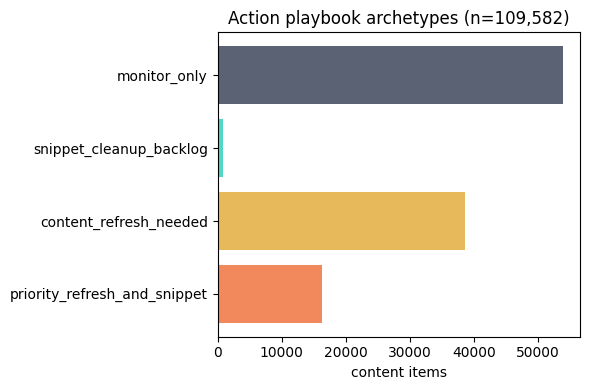

Saved work/figures/archetype_breakdown.png

All figures saved to work/figures/ -- commit these (they are the receipts).
Metrics JSON already committed at work/outputs/action_playbook_metadata.json (from w07).


In [7]:
# Archetype breakdown figure
fig, ax = plt.subplots(figsize=(6, 4))
archetype_order = ["priority_refresh_and_snippet", "content_refresh_needed",
                    "snippet_cleanup_backlog", "monitor_only"]
vals = [counts_out.get(a, 0) for a in archetype_order]
colors = ["#f2895d", "#e8b95a", "#52d6c8", "#5b6274"]
ax.barh(archetype_order, vals, color=colors)
ax.set_xlabel("content items")
ax.set_title(f"Action playbook archetypes (n={len(model_df):,})")
plt.tight_layout()
plt.savefig("work/figures/archetype_breakdown.png", dpi=150)
plt.show()
print("Saved work/figures/archetype_breakdown.png")

print("\nAll figures saved to work/figures/ -- commit these (they are the receipts).")
print("Metrics JSON already committed at work/outputs/action_playbook_metadata.json (from w07).")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.